# L4.3 — Positional Encoding (Sinusoidal, Learned, RoPE)

Hands-on notebook for the lesson [`4-3-positional-encoding.mdx`](../../llm-quest-theory/level-4/4-3-positional-encoding.mdx).

> **Learning objectives**
> - Prove that plain self-attention is **permutation equivariant** — shuffling inputs reshuffles outputs identically.
> - Build the 2017 sinusoidal encoding and visualize the multi-frequency pattern.
> - Implement a learned positional embedding.
> - Write a minimal RoPE and verify its key property: `q'·k'` depends only on the position difference `i - j`.

## Connection to the theory
Covers **§1–§8** of the source `.mdx`. By the end you will see exactly why modern LLMs (LLaMA, Mistral, Qwen) reach for RoPE — and why learned positions struggle to extrapolate.

In [1]:
# ---- Setup ----
import numpy as np
import matplotlib.pyplot as plt
import torch
from torch import nn

SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)
plt.rcParams["figure.figsize"] = (6, 4)
plt.rcParams["figure.dpi"] = 100
%matplotlib inline

## 1. Self-attention without PE is permutation equivariant
Shuffle the input rows; each output row also shuffles, but the *set* of output vectors is unchanged. That is why attention alone has no notion of order.

In [2]:
def softmax(x, axis=-1):
    x = x - x.max(axis=axis, keepdims=True)
    e = np.exp(x)
    return e / e.sum(axis=axis, keepdims=True)

def self_attn(X):
    d_k = X.shape[-1]
    attn = softmax(X @ X.T / np.sqrt(d_k), axis=-1)
    return attn @ X

T, d = 5, 8
X = np.random.randn(T, d)
out_original = self_attn(X)

# Shuffle rows
perm = np.array([2, 0, 4, 1, 3])
out_shuffled = self_attn(X[perm])

# Equivariance: out_shuffled[i] should equal out_original[perm[i]]
print("max diff between out_shuffled and out_original[perm]:",
      float(np.max(np.abs(out_shuffled - out_original[perm]))))

max diff between out_shuffled and out_original[perm]: 4.440892098500626e-16


Zero to floating-point precision — shuffling input rows shuffles output rows identically. Attention doesn't care about order. We have to inject position information some other way.

## 2. Sinusoidal positional encoding (Vaswani 2017)

$$PE_{pos, 2i}     = \sin\!\left(pos / 10000^{2i/d_{model}}\right)$$
$$PE_{pos, 2i+1}   = \cos\!\left(pos / 10000^{2i/d_{model}}\right)$$

PE.shape: (64, 32)


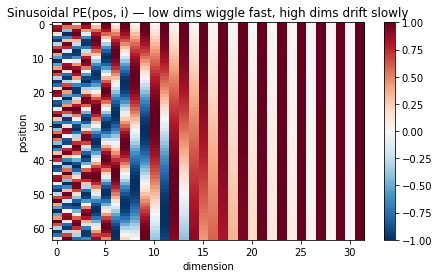

In [3]:
def sinusoidal_pe(T, d_model):
    pos = np.arange(T)[:, None]                     # (T, 1)
    i   = np.arange(d_model)[None, :]               # (1, d)
    # Same denominator for the pair (2i, 2i+1)
    div = 10000 ** ((i - i % 2) / d_model)
    pe  = np.where(i % 2 == 0, np.sin(pos / div), np.cos(pos / div))
    return pe

PE = sinusoidal_pe(T=64, d_model=32)
print("PE.shape:", PE.shape)

fig, ax = plt.subplots(figsize=(7, 4))
im = ax.imshow(PE, aspect="auto", cmap="RdBu_r", vmin=-1, vmax=1)
ax.set_xlabel("dimension"); ax.set_ylabel("position")
ax.set_title("Sinusoidal PE(pos, i) — low dims wiggle fast, high dims drift slowly")
plt.colorbar(im, ax=ax); plt.show()

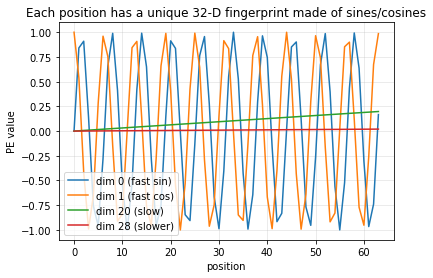

In [4]:
# Look at two dimensions: a fast and a slow one.
fig, ax = plt.subplots()
ax.plot(PE[:, 0],  label="dim 0 (fast sin)")
ax.plot(PE[:, 1],  label="dim 1 (fast cos)")
ax.plot(PE[:, 20], label="dim 20 (slow)")
ax.plot(PE[:, 28], label="dim 28 (slower)")
ax.set_xlabel("position"); ax.set_ylabel("PE value")
ax.grid(alpha=0.3); ax.legend()
ax.set_title("Each position has a unique 32-D fingerprint made of sines/cosines")
plt.show()

## 3. Injecting PE breaks the equivariance
After adding PE to the inputs, shuffling rows no longer gives a shuffled output. The model now "knows" position 0 from position 4.

In [5]:
# Shuffle TOKENS while keeping PE pinned to each position slot.
X5    = np.random.randn(5, 16)
PE5   = sinusoidal_pe(5, 16)

# Baseline: natural order + PE
out_original = self_attn(X5 + PE5)

# Permuted: tokens shuffled but PE stays at the same slots
perm = np.array([2, 0, 4, 1, 3])
out_token_shuffled = self_attn(X5[perm] + PE5)

# If PE had no effect, equivariance would give out_token_shuffled[i] == out_original[perm[i]].
# With PE actively tagging positions, they differ.
diff = float(np.max(np.abs(out_token_shuffled - out_original[perm])))
print("with PE, |shuffled-tokens vs permuted-original| =", round(diff, 4), "(should be > 0)")

with PE, |shuffled-tokens vs permuted-original| = 1.5249 (should be > 0)


## 4. Learned positional embedding
A simple lookup table. Trains fine for positions seen during training — but has no clue what to do for positions larger than `max_len`.

In [6]:
class LearnedPE(nn.Module):
    def __init__(self, max_len, d_model):
        super().__init__()
        self.pe = nn.Embedding(max_len, d_model)
    def forward(self, T):
        positions = torch.arange(T)
        return self.pe(positions)

pe_learned = LearnedPE(max_len=64, d_model=32)
print("learned PE for T=5:", pe_learned(5).shape)
# Asking for T=128 would blow up because the lookup only has 64 rows.
try:
    pe_learned(128)
except IndexError as e:
    print("learned PE for T=128 raises:", type(e).__name__)

learned PE for T=5: torch.Size([5, 32])
learned PE for T=128 raises: IndexError


That is exactly why BERT/GPT-2 (both with learned PE) cannot be stretched past their training context without surgery.

## 5. RoPE — rotate `q` and `k` by position
For each dim pair `(2i, 2i+1)`, rotate by an angle `theta_i * pos`:

$$\begin{bmatrix} q'_{2i} \\ q'_{2i+1} \end{bmatrix} = \begin{bmatrix} \cos(\theta_i \cdot pos) & -\sin(\theta_i \cdot pos) \\ \sin(\theta_i \cdot pos) & \cos(\theta_i \cdot pos) \end{bmatrix}\begin{bmatrix} q_{2i} \\ q_{2i+1} \end{bmatrix}$$

Where `theta_i = 10000^(-2i/d)`. The stunning consequence: after rotation, `q'·k'` depends only on the difference `i - j`.

In [7]:
def rope_frequencies(d, base=10000.0):
    # Shape: (d/2,) — one angle per dim-pair
    return 1.0 / (base ** (np.arange(0, d, 2) / d))

def rope_rotate(x, pos, freqs):
    """x: (d,)  pos: int  freqs: (d/2,).  Returns rotated vector (d,)."""
    x = x.copy()
    angles = pos * freqs                              # (d/2,)
    cos, sin = np.cos(angles), np.sin(angles)
    x_even = x[0::2]; x_odd = x[1::2]
    rot_even = cos * x_even - sin * x_odd
    rot_odd  = sin * x_even + cos * x_odd
    out = x.copy()
    out[0::2] = rot_even
    out[1::2] = rot_odd
    return out

# Verify: |q'| = |q|
d = 16
q = np.random.randn(d)
freqs = rope_frequencies(d)
for pos in [0, 3, 17, 100]:
    qr = rope_rotate(q, pos, freqs)
    print(f"pos = {pos:>3}  |q| = {np.linalg.norm(q):.4f}  |q'| = {np.linalg.norm(qr):.4f}")

pos =   0  |q| = 4.3707  |q'| = 4.3707
pos =   3  |q| = 4.3707  |q'| = 4.3707
pos =  17  |q| = 4.3707  |q'| = 4.3707
pos = 100  |q| = 4.3707  |q'| = 4.3707


## 6. The "relative position" property
Pick random `q` and `k`. For every pair of positions `(i, j)` with the same difference `delta = i - j`, rotated `q'_i · k'_j` should be identical.

In [8]:
q = np.random.randn(d)
k = np.random.randn(d)
freqs = rope_frequencies(d)

# For each difference delta in [0, 6], compute q'_i · k'_{i-delta} at several i
pairs = []
for delta in [0, 1, 3, 6]:
    vals = []
    for i in [5, 11, 17, 23]:                       # arbitrary starting positions
        j  = i - delta
        qr = rope_rotate(q, i, freqs)
        kr = rope_rotate(k, j, freqs)
        vals.append(qr @ kr)
    pairs.append((delta, vals))

for delta, vals in pairs:
    spread = max(vals) - min(vals)
    print(f"delta = {delta}  dot products = {[round(v, 4) for v in vals]}   spread = {spread:.2e}")

delta = 0  dot products = [6.1566, 6.1566, 6.1566, 6.1566]   spread = 0.00e+00
delta = 1  dot products = [5.2371, 5.2371, 5.2371, 5.2371]   spread = 8.88e-16
delta = 3  dot products = [3.7726, 3.7726, 3.7726, 3.7726]   spread = 4.44e-16
delta = 6  dot products = [2.9783, 2.9783, 2.9783, 2.9783]   spread = 1.33e-15


Spread ≈ 0 for every `delta` — the rotated dot product depends on the difference of positions, not on their absolute values. That is exactly why RoPE generalises to longer contexts.

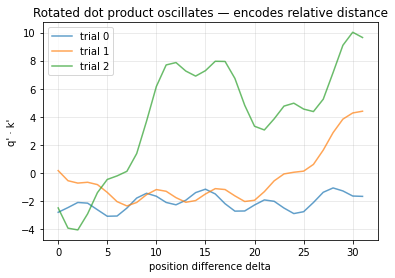

In [9]:
# Visualise how the dot product varies with delta for several (q, k) pairs
deltas = np.arange(0, 32)
fig, ax = plt.subplots()
for trial in range(3):
    q = np.random.randn(d); k = np.random.randn(d)
    dots = []
    for delta in deltas:
        qr = rope_rotate(q, 0,     freqs)           # anchor at 0
        kr = rope_rotate(k, delta, freqs)           # slide k along positions
        dots.append(qr @ kr)
    ax.plot(deltas, dots, alpha=0.7, label=f"trial {trial}")
ax.set_xlabel("position difference delta"); ax.set_ylabel("q' · k'")
ax.grid(alpha=0.3); ax.legend()
ax.set_title("Rotated dot product oscillates — encodes relative distance")
plt.show()

## 7. Comparison summary

In [10]:
rows = [
    ("Sinusoidal",   "0 learned params",  "Moderate",  "Original Transformer, T5"),
    ("Learned",      "max_len * d",       "Poor",      "BERT, GPT-2"),
    ("RoPE",         "0 learned params",  "Excellent", "LLaMA, Mistral, Qwen"),
    ("ALiBi",        "0 learned params",  "Excellent", "BLOOM"),
]
print(f"{'Type':<14}{'Params':<22}{'Generalisation':<15}{'Used in'}")
print("-" * 75)
for r in rows:
    print(f"{r[0]:<14}{r[1]:<22}{r[2]:<15}{r[3]}")

Type          Params                Generalisation Used in
---------------------------------------------------------------------------
Sinusoidal    0 learned params      Moderate       Original Transformer, T5
Learned       max_len * d           Poor           BERT, GPT-2
RoPE          0 learned params      Excellent      LLaMA, Mistral, Qwen
ALiBi         0 learned params      Excellent      BLOOM


## 8. Quick checks

In [11]:
# With PE pinned to slots, shuffling tokens changes the outputs.
assert np.max(np.abs(out_token_shuffled - out_original[perm])) > 1e-3
# (Earlier we already showed plain self-attention is equivariant: out_shuffled == out_anchor[perm0].)
# RoPE preserves length exactly.
q_check = np.random.randn(d)
assert abs(np.linalg.norm(rope_rotate(q_check, 42, freqs)) - np.linalg.norm(q_check)) < 1e-10
# RoPE dot product depends only on delta.
for delta, vals in pairs:
    assert max(vals) - min(vals) < 1e-9, f"RoPE dot should be invariant to i for delta={delta}"
print("OK — self-attention is position-blind; PE fixes that; RoPE encodes relative distance.")

OK — self-attention is position-blind; PE fixes that; RoPE encodes relative distance.


## Reflection questions

1. BERT and GPT-2 use learned PE. Why can't they simply be fed longer sequences at inference time? What breaks, geometrically?
2. In section 6 we showed `q' · k'` depends only on `delta`. How does this help the model generalize to sequences longer than training?
3. ALiBi adds a linear penalty `-m * |i - j|` directly to the attention logits. What would break if we used `-m * (i - j)^2`?
4. Could you combine RoPE with a learned PE additively? What might that buy or cost?

## References
- Source theory: [`4-3-positional-encoding.mdx`](../../llm-quest-theory/level-4/4-3-positional-encoding.mdx)
- Next: [`4-4-multi-head`](4-4-multi-head.ipynb)